# Actividad Final Módulo 5:

# Estudiante: Daniela Quiroga Reyes.



Usted ha sido contratado en el ministerio de educación para analizar los resultados de una nueva metodología de educación implementada en el colegio Graham Parker (GP), versus el colegio Marteen Sheen (MS), en donde no fue aplicada la metodología.

Ambos colegios han tenido históricamente desempeños similares en las notas de sus alumnos. En base a los datos del archivo en formato csv llamado notas-alumnos.csv, disponible en plataforma SENCE, aplique sus conocimientos de estadística inferencial para determinar si esta nueva metodología de educación aplicada produjo una mejora significativa en el promedio de los estudiantes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [2]:
df = pd.read_csv('notas-alumnos.csv')

1.- Planteamiento del problema.

-Tengo 2 colegios:

- El colegio GP (Graham Parker) → aplicó una nueva metodología.

- El colegio MS (Marteen Sheen) → no aplicó esa nueva metodología (grupo control).

-Históricamente ambos colegios tenían desempeño similar.

-Lo que quiero es evaluar si la metodología produjo una mejora significativa en el promedio final.

-Para ello tomaré como variable de desempeño la nota final N3 (nota final del curso).

2.- Análisis exploratorio inicial.

2.1- Reviso la estructura del dataframe con .head() e .info().

In [3]:
df.head ()

,colegio,sexo,edad,ausencias,N1,N2,N3
0,GP,F,18,6,1.8,2.1,2.1
1,GP,F,17,4,1.8,1.8,2.1
2,GP,F,15,10,2.4,2.8,3.5
3,GP,F,15,2,5.2,4.9,5.2
4,GP,F,16,4,2.1,3.5,3.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   colegio    395 non-null    object 
 1   sexo       395 non-null    object 
 2   edad       395 non-null    int64  
 3   ausencias  395 non-null    int64  
 4   N1         395 non-null    float64
 5   N2         395 non-null    float64
 6   N3         395 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 21.7+ KB


A simple vista no se aprecia ningún valor nulo. Veo que tengo un dataframe con un total de 395 filas y 7 columnas.

2.2- Identifico los tipos de variable de cada atributo del set de datos.

Tengo 7 columnas en mi dataframe repesentando cada una un atributo de mi set de datos. Estas columnas son:

- colegio: Se trata de una variable cualitativa nominal que o tiene orden e indica el establecimiento educacional del estudiante:

GP → Corresponde al colegio Graham Parker (metodología nueva).

MS → Corresponde al colegio Marteen Sheen (grupo control).

- sexo: Se trata de una varible cualitaiva nominal dicotómica y representa el sexo del estudiante:

F → Si el estudiante es de sexo femenino

M → si el estudiante es de sexo masculino

- edad: Se trata de una variable cuantitativa discreta, porque toma valores enteros y es la edad del estudiante (en años).

- ausencias: Se trata de una variable cuantitativa discreta, ua que es un conteo de eventos, en este caso de las ausencias y corresponde a la cantidad de inasistencias del estudiante.

- Finalmente las columnas N1, N2 y N3: Corresponden a variables cuantitativa continua. Se consideran continuas porque pueden tomar decimales y representan las notas del estudiante:

N1 → nota del primer periodo

N2 → nota del segundo periodo

N3 → nota final

2.3- Tranformación de las columnas colegio y sexo a tipo de dato categórico.

- La variable "colegio" corresponde a una variable cualitativa nominal, ya que clasifica a los estudiantes en dos grupos mutuamente excluyentes (GP y MS) sin que exista un orden inherente entre ellos. Decido transformar su tipo de dato de object a category en pandas, con el objetivo de representar adecuadamente su naturaleza categórica, optimizar el uso de memoria y mejorar la eficiencia en operaciones de agrupación y análisis estadístico. Esta transformación asegura coherencia entre la naturaleza estadística de la variable y su representación en el entorno de análisis, evitando interpretaciones incorrectas como variable numérica.

- La variable "sexo" es una variable cualitativa nominal dicotómica con sólo dos opciones F o M, por ello, también decido transformar su tipo de dato de object a category en pandas.

In [5]:
df["colegio"] = df["colegio"].astype("category")
df["sexo"] = df["sexo"].astype("category")

3.- Análisis de valores nulos y consistencia.

3.1-Cuento los valores nulos por columna para su detección.

In [6]:
df.isnull().sum()

,0
colegio,0
sexo,0
edad,0
ausencias,0
N1,0
N2,0
N3,0


No hay valores nulos en mi dataframe.

3.2- Detecto filas duplicadas.

In [7]:
df[df.duplicated()]

,colegio,sexo,edad,ausencias,N1,N2,N3
115,GP,M,16,2,5.2,5.2,5.6
207,GP,F,16,10,3.9,4.2,4.6
249,GP,M,16,0,4.6,5.2,5.2
319,GP,F,18,2,3.9,3.9,3.9
332,GP,F,18,0,2.4,0.0,0.0
333,GP,F,18,0,2.8,2.8,0.0
339,GP,F,17,4,3.2,3.5,3.5
365,MS,M,18,4,3.5,3.5,3.5


Mii código me devuelve 8 filas. Esto quiere decir que tengo 8 filas duplicadas en mi dataframe.

3.3- Elimino filas duplicadas de mi dataframe.

In [8]:
df = df.drop_duplicates()

3.4.- Ocupo el método .shape y veo que ahora mi datframe ahora tiene 387 filas y 7 columnas.

In [9]:
df.shape

(387, 7)

Hasta este punto concluyo que mi dataset es consistente, sin valores faltantes ni filas duplicadas.

4.- Estadísticas descriptivas: Obtengo resumen estadístico rápido con el método .describe()

In [10]:
df.describe ()

,edad,ausencias,N1,N2,N3
count,387.000000,387.000000,387.000000,387.000000,387.000000
mean,16.687339,5.770026,3.827649,3.765116,3.662016
std,1.280754,8.061379,1.169423,1.306579,1.590330
min,15.000000,0.000000,1.000000,0.000000,0.000000
25%,16.000000,0.000000,2.800000,3.200000,2.800000
50%,17.000000,4.000000,3.900000,3.900000,3.900000
75%,18.000000,8.000000,4.600000,4.600000,4.900000
max,22.000000,75.000000,6.600000,6.600000,7.000000


El análisis descriptivo al dataframe completo, muestra que la muestra está compuesta por 387 estudiantes y la población es homogénea en edad, con una edad promedio de 16.69 años. Las ausencias presentan una alta dispersión con una distribución asimétrica positiva, evidenciando la presencia de posibles valores extremos.

En cuanto al rendimiento académico, se observa una leve disminución progresiva en las medias de N1 (3.83), N2 (3.77) y N3 (3.66), junto con un aumento en la dispersión. Las notas muestran variabilidad creciente hacia la evaluación final.siendo N3 la variable con mayor variabilidad (std = 1.59). Estos resultados sugieren heterogeneidad en el desempeño final, lo cual justifica la aplicación de técnicas de inferencia estadística para comparar los promedios entre establecimientos.

4.1- Estadísticos descriptivos por colegio.

Mi siguiente bloque de código calcula estadísticos descriptivos de la nota final (N3) para cada colegio por separado.

In [11]:
df.groupby("colegio", observed=True)["N3"].agg(["mean", "std", "count"])

,mean,std,count
colegio,,,
GP,3.689181,1.602299,342
MS,3.455556,1.497051,45


El análisis descriptivo por colegio muestra que el colegio  Graham Parker (GP) presenta una media de nota final (N3) de 3.689, mientras que el colegio Marteen Sheen (MS) presenta una media de 3.456. La diferencia observada entre ambos grupos es de 0.233 puntos a favor del colegio GP.

Las desviaciones estándar son similares (1.60 en el Graham Parker (GP) y 1.50 en el Marteen Sheen (MS)), lo que sugiere una dispersión comparable en ambos grupos. Sin embargo, se observa un desbalance en los tamaños muestrales (n=342 el del Graham Parker (GP) y n=45 el del Marteen Sheen (MS)), lo cual debe considerarse en el análisis inferencial posterior.

5.- Calculo outliers en cada columna numérica.

In [12]:
# Seleccionar solo columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns

for col in columnas_numericas:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"Columna: {col}")
    print(f"Cantidad de outliers detectados: {outliers.shape[0]}")
    print("-" * 50)


Columna: edad
Cantidad de outliers detectados: 1
--------------------------------------------------
Columna: ausencias
Cantidad de outliers detectados: 15
--------------------------------------------------
Columna: N1
Cantidad de outliers detectados: 0
--------------------------------------------------
Columna: N2
Cantidad de outliers detectados: 12
--------------------------------------------------
Columna: N3
Cantidad de outliers detectados: 0
--------------------------------------------------


De mis columnas numéricas, tengo 3 con outliers:

La columna edad con 1 outlier, la columna asusencias con 15 outliers y la columna N2 con 12 outliers.

5.1- Boxplots Distribución Nota Segundo Periodo (N1) por Colegio, Distribución Nota Segundo Periodo (N2) por Colegio y Distribución Nota Final (N3) por Colegio.

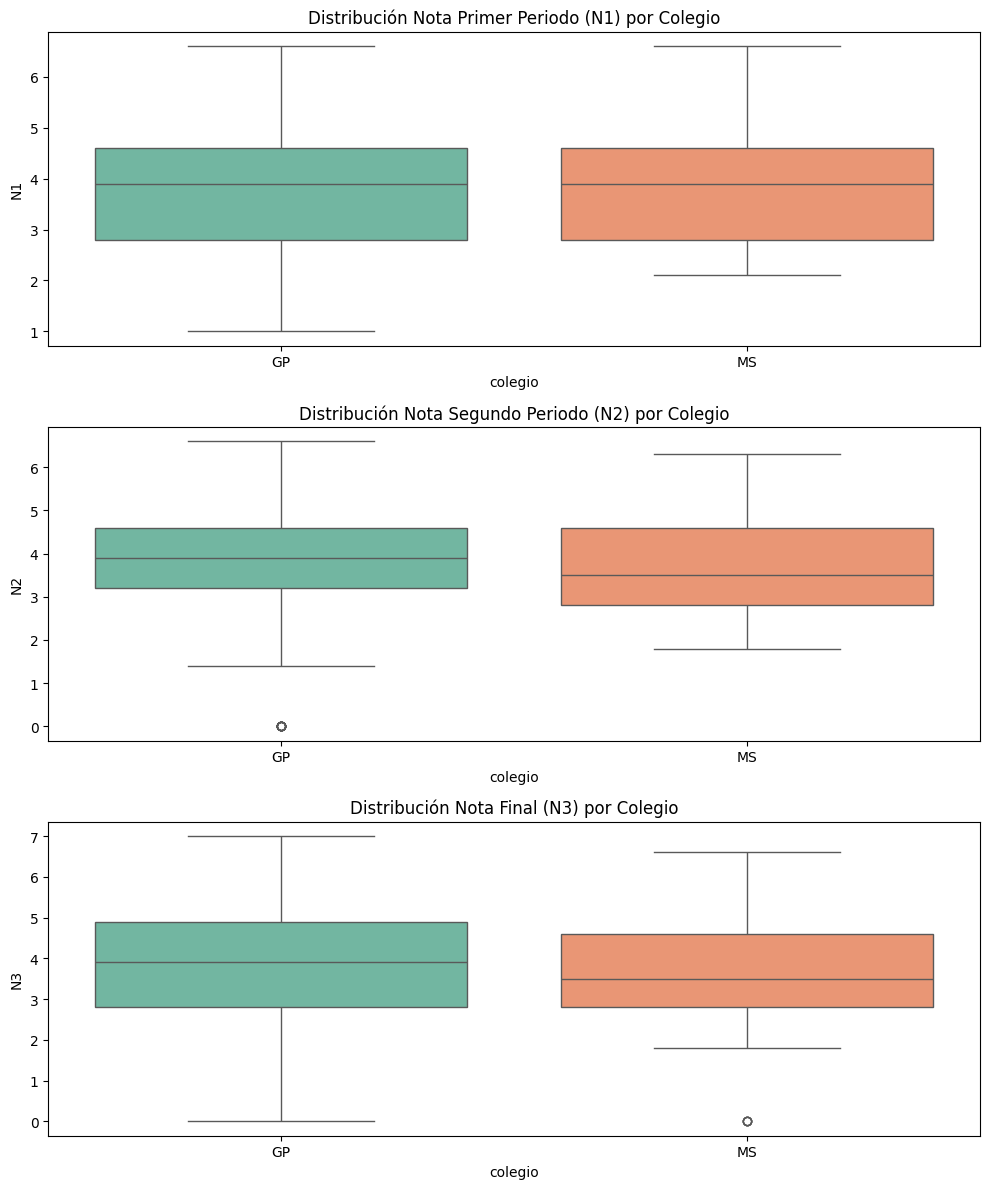

In [13]:
## Configuro el tamaño de la figura
plt.figure(figsize=(10, 12))

# 1. Boxplot para N1
plt.subplot(3, 1, 1)
# Añado hue="colegio" y legend=False para evitar el warning
sns.boxplot(x="colegio", y="N1", data=df, hue="colegio", palette="Set2", legend=False)
plt.title("Distribución Nota Primer Periodo (N1) por Colegio")

# 2. Boxplot para N2
plt.subplot(3, 1, 2)
sns.boxplot(x="colegio", y="N2", data=df, hue="colegio", palette="Set2", legend=False)
plt.title("Distribución Nota Segundo Periodo (N2) por Colegio")

# 3. Boxplot para N3
plt.subplot(3, 1, 3)
sns.boxplot(x="colegio", y="N3", data=df, hue="colegio", palette="Set2", legend=False)
plt.title("Distribución Nota Final (N3) por Colegio")

plt.tight_layout()
plt.show()

- Periodo N1 (Punto de partida): Ambos colegios comienzan de forma casi idéntica. Las medianas están alineadas cerca de la nota 4.0 y la dispersión es muy similar. Esto confirma la premisa inicial: históricamente, los colegios tenían desempeños parejos.

- Periodo N2 (Transición): Se empieza a notar una ligera ventaja para el colegio Graham Parker (GP). Mientras que la mediana del colegio Graham Parker (GP) se mantiene sólida, la del Marteen Sheen (MS) comienza a caer hacia el 3.5. Aparece el primer valor atípico (cero) en el ccolegio Graham Parke.

- Periodo N3 (Resultado Final): La diferencia es más marcada.

- La mediana del colegio Graham Parker es claramente superior a la del colegio Marteen Sheen (MS).

- La "caja" del colegio Graham Parker (que contiene el 50% central de los alumnos) está situada en un rango de notas más alto que la del colegio Marteen Sheen (MS).

- Sin embargo, el colegio Graham Parker muestra una mayor extensión hacia abajo (bigote inferior), lo que indica que, aunque la metodología ayuda a la mayoría, hay un grupo pequeño que no logra adaptarse.

5.2.- Decido que hacer con los outliers.

Analizo las 3 columnas numéricas que presentan outliers para tomar una decisión.

A) Columna N2: Aunque N2 tiene 12 valores atípicos, el gráfico de caja (box plot) muestra que están en el límite inferior (cerca de 0), esto quiere decir que son datos reales y podemos deducir que se tratan de alumnos que simplemente no se presentarona a las evaluación, ya que al encontrar que los evaluadores también han colocado notas 1, quiere decir que hacen la diferencia y cuando los estudiantes se presentan a evaluación pero no aciertan a ninguna respuesta los evaluan con nota 1. Al tratarse de datos reales no se deben imputar ni eliminar.

B) Columna ausencias: Presenta 15 outliers con un valor máximo de 75 ausencias (cuando el 75% de los alumnos tiene 8 o menos), este dato es un outlier extremo que distorsiona completamente la desviación estándar (std = 8.06). En este caso, sí es imperativo tratarlos (ya sea mediante winsorización o eliminación), porque las ausencias suelen ser una variable confusora.

C) Columna edad: Posee 1 outlier y al ser solo uno y considerando que el máximo es 22 años (frente a una media de 16), el impacto en el promedio general es despreciable. Puedes dejarlo y no cambiará mi conclusión final.

# Decido tratar sólo los outliers de la columna ausencias.

5.3- Trato los outliers de la columna ausencias con winsorización.

In [15]:
# 1. CalculO el IQR (Rango Intercuartílico)
Q1 = df['ausencias'].quantile(0.25)
Q3 = df['ausencias'].quantile(0.75)
IQR = Q3 - Q1

# 2. Defino los límites (Upper Bound)
# Generalmente se usa 1.5 * IQR para detectar outliers,
limite_superior = Q3 + 1.5 * IQR

print(f"Límite superior calculado: {limite_superior}")

# 3. Aplico Capping (Tratamiento de outliers)
# En lugar de eliminar las filas, reemplazo los valores que superan el límite
# con el valor del límite mismo. Esto mantiene el tamaño de la muestra (n=387).
df['ausencias_tratadas'] = np.where(
    df['ausencias'] > limite_superior,
    limite_superior,
    df['ausencias']
)

# 4. Verificación rápida
print(df[['ausencias', 'ausencias_tratadas']].describe())

Límite superior calculado: 20.0
        ausencias  ausencias_tratadas
count  387.000000          387.000000
mean     5.770026            5.237726
std      8.061379            5.724262
min      0.000000            0.000000
25%      0.000000            0.000000
50%      4.000000            4.000000
75%      8.000000            8.000000
max     75.000000           20.000000


Corroboré que los outliers de la columna ausencias fueron correctamente tratados. La winsorización es el mejor método porque:

- Mantiene el tamaño de la muestra: En mi caso tengo 387 registros. Si borro los 15 outliers de golpe, reduzco la potencia estadística para comparar los colegios GP y MS.

- Reduce el sesgo de la media: El valor máximo de 75 desplaza la media hacia arriba de forma artificial. Al limitar ese valor a, en mi caso, 20 (según el cálculo de IQR), la media se vuelve más representativa del alumno típico.

- No asume normalidad: El método IQR funciona bien aunque los datos de ausencias suelan tener una distribución sesgada (mucha gente con 0 ausencias y pocos con muchas).

6.- Gráfico distribución de Notas Finales (N3) por Colegio.

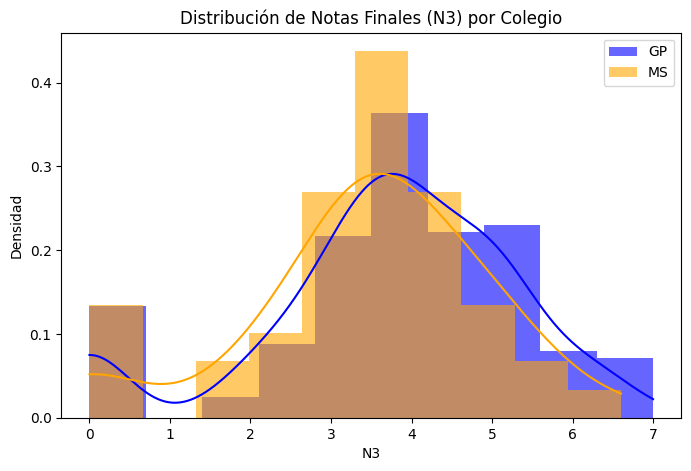

In [22]:
from scipy.stats import gaussian_kde

# Separar los datos por colegio
n3_gp = df[df["colegio"] == "GP"]["N3"]
n3_ms = df[df["colegio"] == "MS"]["N3"]

plt.figure(figsize=(8,5))

# Histograma de GP
plt.hist(n3_gp, bins=10, alpha=0.6, label='GP', color='blue', density=True)

# Histograma de MS
plt.hist(n3_ms, bins=10, alpha=0.6, label='MS', color='orange', density=True)

# Curvas KDE aproximadas usando gaussian_kde
x_gp = np.linspace(n3_gp.min(), n3_gp.max(), 1000)
x_ms = np.linspace(n3_ms.min(), n3_ms.max(), 1000)
plt.plot(x_gp, gaussian_kde(n3_gp)(x_gp), color='blue')
plt.plot(x_ms, gaussian_kde(n3_ms)(x_ms), color='orange')

plt.title("Distribución de Notas Finales (N3) por Colegio")
plt.xlabel("N3")
plt.ylabel("Densidad")
plt.legend()
plt.show()


Visualmente, el Colegio Graham Parker (GP) muestra un desempeño superior en las notas finales (N3) en comparación con el Marteen Sheen (MS), especialmente en el segmento de alumnos con mejor rendimiento.

7.- Principales insights encontrados en mi análisis Exploratoro.

- Detecté 8 registros duplicados y los eliminé para asegurar la independencia de observaciones. El amaño final de mi  muestra resultó ser n = 387 estudiantes , por lo que mi base  base quedó depurada y metodológicamente válida para inferencia.

- Al analizar la distribucion por colegios, existe un fuerte desbalance muestral, (n=342, tamaño de muestra del colegio Graham Parker y n=45 tamaño de muestra del colegio Marteen Sheen). El colegio Graham Parker (GP) concentra la mayoría de los estudiantes pudiendo considerarse una limitación.

- El colegio Graham Parker (GP) tiene una media 0.233 puntos mayor que el colegio Marteen Sheen (MS), sus desviaciones estándar son similares y no hay outliers en N3. Este puede ser un indicio preliminar de posible efecto positivo de la nueva metodología, pero, hasta este punto de mi trabajo aún no se si es estadísticamente significativo.

- Existe una leve disminución progresiva del rendimiento y la variabilidad aumenta en N3. Esto sugiere un mayor heterogeneidad en el desempeño final.

- Procedí al tratamiento de los 15 outliers en la variable Ausencias mediante la técnica de Winsorización (Capping). Mi decisión se justifica en la prevención de que casos de ausentismo extremo distorsionen la varianza de la muestra y actúen como variables intervinientes que oculten el impacto real de la nueva metodología educativa en el desempeño académico final.

- En resumen, existe una diferencia descriptiva favorable al colegio Graham Parker (GP), aunque la diferencia no parece extremadamente grande (0.23 puntos) y la variabilidad es similar entre grupos. Por otra parte, el desbalance muestral podría comportarse como una limitación y la calidad de mis datos es adecuada tras la depuración que realicé.

8.- Aplico con Python el Test de Normalidad (Shapiro).

In [17]:
from scipy.stats import shapiro

gp = df[df["colegio"]=="GP"]["N3"]
ms = df[df["colegio"]=="MS"]["N3"]

shapiro(gp)
shapiro(ms)

ShapiroResult(statistic=np.float64(0.9330068281232791), pvalue=np.float64(0.011995893327497068))

9.- Aplico en Python el Test de Homogeneidad de Varianzas (Levene).

In [18]:
from scipy.stats import levene

levene(gp, ms)

LeveneResult(statistic=np.float64(0.48968116729614514), pvalue=np.float64(0.48449215594434947))

10.- Interpreto mis resultados del Test de Normalidad (Shapiro) y del Test de Homogeneidad de Varianzas (Levene) para decidir que test estadístico utilizaré.

El test de normalidad de Shapiro-Wilk Utilizando el umbral estándar de alpha = 0.05 (5%), dio como resultados estadístico (W) 0.933 y p-valor (0.011), como este último es menor a 0.05, rechazo la hipótesis nula de normalidad. Mis datos no siguen una distribución normal perfecta y hay un sesgo o curtosis que los aleja de la campana de Gauss.

Test de homogeneidad de Varianzas (Levene) arrojó como resultados estadístico (W): 0.489 y p-valor: 0.484 (aproximadamente 48.4%). Como el p-valor (0.484) es mucho mayor a 0.05, no puedo rechazar la hipótesis nula. Existe homogeneidad de varianzas, lo que significa que, aunque los promedios puedan ser distintos, la "dispersión" o incertidumbre de las notas es similar en ambos colegios. Esto es un punto a favor para la comparabilidad de los grupos.

11.- Definición del Problema Estadístico.

- Mi parámero de interés será la media poblacional de notas finales:

   #    μGP , μMS

- Hipótesis: Planteo las siguientes hipótesis (es una prueba unilateral a la derecha):

  # H0 : μGP ≤ μMS
  # H1 : μGP > μMS

Donde μGP representa la media poblacional de la nota final (N3) del colegio que implementó la nueva metodología, (el Graham Parker), y μMS representa la media del colegio que no la implementó (el Marteen Sheen). El contraste es unilateral a la derecha, dado que el interés del estudio es determinar si la metodología genera una mejora en el rendimiento académico.

- Nivel de significancia:

  # α=0.05


12.- Decido que test estadístico usaré.

Dada la marcada disparidad en el tamaño de las muestras de ambos colegios nGP=342, nMS=45, opté por utilizar la versión de Welch del test t. Aunque el test de Levene mostró homogeneidad en las varianzas, la t de Welch ofrece un control superior sobre el Error Tipo I en diseños no balanceados, garantizando que la heterogeneidad potencial no infle los resultados de significancia pedagógica.

13.- Fórmula de la versión de Welch del test t

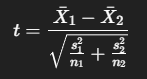

A diferencia del t clásico:

- No usa varianza combinada.

- Ajusta los grados de libertad (fórmula de Welch-Satterthwaite).

- Es más robusto ante tamaños desiguales.

14.- Ejecuto en Python la versión de Welch del test t.

In [19]:
from scipy.stats import ttest_ind

# Separo grupos
gp = df[df["colegio"] == "GP"]["N3"]
ms = df[df["colegio"] == "MS"]["N3"]

# Welch test
t_stat, p_value = ttest_ind(gp, ms, equal_var=False)

print("Estadístico t:", t_stat)
print("Valor p bilateral:", p_value)

# Como mi hipótesis es unilateral:
p_unilateral = p_value / 2
print("Valor p unilateral:", p_unilateral)

Estadístico t: 0.9758961345461076
Valor p bilateral: 0.33316230486330256
Valor p unilateral: 0.16658115243165128


El estadístico que obtuve fue t = 0.976 con un valor p unilateral de 0.167.

Dado que el valor p resultó ser mayor que el nivel de significancia α = 0.05, no rechazo la hipótesis nula. Además, como el valor p unilateral es mayor que 0.05 (0.167 > 0.05), no tengo evidencia estadísticamente significativa para afirmar que la metodología mejora el promedio final.

15.- Fórmula para calcular el tamaño del efecto.

Calcularé el tamaño del efecto a través de Cohen's d. A diferencia de un valor p, (que sólo te dice si un resultado es "estadísticamente significativo"), la d de Cohen o Cohen's  d  te dice qué tan grande o importante es esa diferencia en la vida real.

Su fórmula es la siguiente:

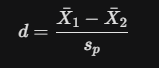

Donde:

- x̅1 y x̅2 son las medias (promedios) de los dos grupos que estás comparando.

- Y sp es la desviación estándar agrupada (pooled standard deviation). Es básicamente un promedio de la variabilidad de ambos grupos.

En términos sencillos, estoy dividiendo la diferencia entre los grupos por su "ruido" o variabilidad natural. El resultado te dice a cuántas desviaciones estándar de distancia está un grupo del otro.


16.- Calculo con Python Cohen’s d.

In [20]:
mean_gp = np.mean(gp)
mean_ms = np.mean(ms)

std_gp = np.std(gp, ddof=1)
std_ms = np.std(ms, ddof=1)

n1 = len(gp)
n2 = len(ms)

# Desviación estándar combinada
sp = np.sqrt(((n1-1)*std_gp**2 + (n2-1)*std_ms**2)/(n1+n2-2))

cohen_d = (mean_gp - mean_ms)/sp

print("Cohen's d:", cohen_d)

Cohen's d: 0.14687689524479708


El efecto resultó ser muy pequeño (menor a 0.2)

17.- Calculo con Python el intervalo de confianza.

In [21]:
import statsmodels.stats.api as sms

cm = sms.CompareMeans(sms.DescrStatsW(gp), sms.DescrStatsW(ms))
ci_low, ci_high = cm.tconfint_diff(usevar='unequal')

print("Intervalo de confianza 95%:", ci_low, ci_high)

Intervalo de confianza 95%: -0.24556119308582308 0.7128126550741303


El intervalo contiene el 0. Cuando el intervalo de confianza incluye 0 la diferencia no es estadísticamente significativa. Mi resultado es coherente con el valor p.

18.- Análisis de mis resultados obtenidos.

Apliqué la versión de Welch del test t para comparar la nota final promedio entre el colegio que implementó la nueva metodología (GP) y el colegio control (MS), específicamente lo que buscaba con esa prueba era que:    
image.png

Los tamaños de muestras fueron: n=342 el tamaño de muestra del colegio Graham Parker y n=45 el tamaño de muestra del colegio Marteen Sheen, existiendo un fuerte desbalance muestral.

El estadístico obtenido fue t = 0.976 con un valor p unilateral de 0.167. Dado que p > 0.05, no se rechaza la hipótesis nula.

El intervalo de confianza del 95% para la diferencia de medias fue (-0.246, 0.713), el cual incluye el valor 0, confirmando la ausencia de significancia estadística.

El tamaño del efecto que calculé mediante Cohen’s d fue 0.147, lo que indica un efecto muy pequeño.

En consecuencia, no existe evidencia estadística suficiente para afirmar que la nueva metodología educativa haya generado una mejora significativa en el rendimiento académico de los estudiantes.

19.- Gráfico Impacto de Metodología: Comparación de Notas Finales (N3).

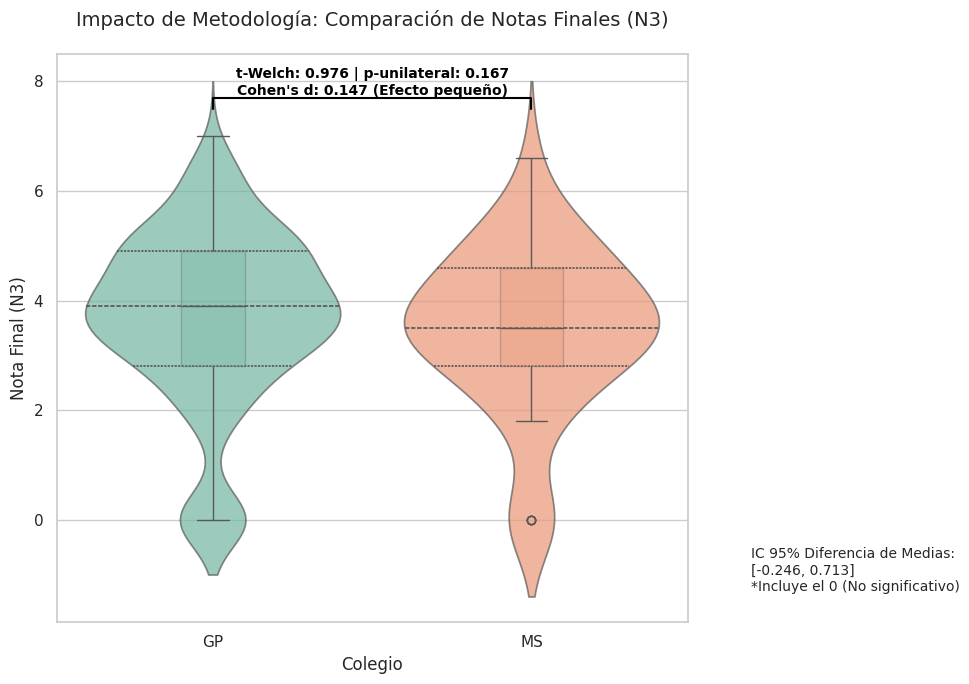

In [24]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# 1. Crear el gráfico de Violín + Boxplot corregido
# Asignamos x a 'hue' y desactivamos la leyenda para eliminar el aviso
ax = sns.violinplot(
    x='colegio',
    y='N3',
    data=df,
    hue='colegio',
    palette={'GP': '#66c2a5', 'MS': '#fc8d62'},
    inner="quartile",
    alpha=0.7,
    legend=False
)

sns.boxplot(
    x='colegio',
    y='N3',
    data=df,
    hue='colegio',
    width=0.2,
    palette={'GP': '#66c2a5', 'MS': '#fc8d62'},
    ax=ax,
    boxprops=dict(alpha=0.3),
    legend=False
)

# 2. Añadir anotaciones de los resultados estadísticos (Basado en tus cálculos anteriores)
x1, x2 = 0, 1
y, h = df['N3'].max() + 0.5, 0.2

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
plt.text((x1+x2)*0.5, y+h, f"t-Welch: 0.976 | p-unilateral: 0.167\nCohen's d: 0.147 (Efecto pequeño)",
         ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

# 3. Cuadro de texto con el Intervalo de Confianza
info_text = (f"IC 95% Diferencia de Medias:\n"
             f"[{ -0.246:.3f}, {0.713:.3f}]\n"
             f"*Incluye el 0 (No significativo)")

plt.gca().text(1.1, 0.05, info_text, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Etiquetas finales
plt.title('Impacto de Metodología: Comparación de Notas Finales (N3)', fontsize=14, pad=20)
plt.xlabel('Colegio', fontsize=12)
plt.ylabel('Nota Final (N3)', fontsize=12)
plt.ylim(top=df['N3'].max() + 1.5)

plt.tight_layout()
plt.show()

El gráfico demuestra que, si bien el colegio Graham Parker (GP) presenta una media levemente superior en términos descriptivos (3.69 vs 3.46), esta diferencia se diluye ante la alta variabilidad y el solapamiento de las distribuciones. La evidencia estadística (p > 0.05 y d de Cohen < 0.2) confirma que la nueva metodología educativa no ha logrado desplazar significativamente la curva de aprendizaje de los estudiantes por sobre el modelo tradicional.

20.- Análisis crítico.

1.- Limitaciones metodológicas del estudio.

A) Diseño no experimental: El estudio corresponde a un diseño observacional comparativo, no a un experimento aleatorizado. Esto implica que no existe asignación aleatoria de estudiantes y no se puede establecer causalidad. Solo se puede hablar de asociación, no de efecto causal directo, por lo que la nueva metodología educativa no puede afirmarse como causa del rendimiento.

B) Desbalance muestral significativo: n=342 es el tamaño de muestra del colegio Graham Parker y n=45 es el tamaño de muestra del colegio Marteen Sheen. Este desbalance reduce precisión en la estimación del grupo del colegio Marteen Sheen, disminuye potencia estadística y amplía el intervalo de confianza y podría estar afectando la capacidad del estudio para detectar diferencias reales.

2.- Posibles fuentes de sesgo.

A) Sesgo de selección: Los estudiantes no fueron asignados aleatoriamente a los colegios y podría existir diferencia en perfil académico inicial, diferencia en motivación o diferencias socioeconómicas estructurales.

B) Sesgo institucional: Diferencias potenciales en calidad docente, infraestructura, clima escolar y exigencia evaluativa. La diferencia en notas podría no reflejar aprendizaje real sino criterios de evaluación distintos.

C) Error de medición: Las notas pueden verse afectadas por la subjetividad del evaluador, por las diferencias en escala real de notas aplicada y por políticas internas de evaluación.


3.- Interpretación crítica del resultado estadístico.

Aunque no se encontró significancia estadística, (el tamaño del efecto fue muy pequeño (d = 0.147)), el intervalo de confianza es amplio y existe incertidumbre considerable. Esto sugiere que si existe efecto, es pequeño.


4.- Sugerencias para futuros estudios.

A) Diseño experimental aleatorizado (RCT): Asignar aleatoriamente estudiantes a metodología tradicional vs nueva metodología, esto permitiría inferencia causal.

B) Control por covariables (modelo multivariado): Aplicar regresión lineal múltiple o ANCOVA e ir controlando por cada una de las variables.

C) Análisis longitudinal: Medir impacto en más de un año académico y medir la evolución del mismo estudiante en el tiempo para finalmente evaluar la diferencia en progreso (la ganancia de aprendizaje).

D) Incrementar tamaño del grupo control. El grupo MS es pequeño (n=45). Aumentar su tamaño mejoraría: la precisión, la potencia estadística y la estabilidad del intervalo de confianza


21.- Conclusión crítica integral.

Aunque el análisis descriptivo mostró una diferencia favorable al colegio que implementó la nueva metodología, el contraste inferencial mediante el test t de Welch no evidenció diferencias estadísticamente significativas.

No obstante, pese a que traté los outliers de la columna asusencias controlando la confusión, el diseño observacional y la ausencia de control por variables de confusión limitan la capacidad del estudio para establecer conclusiones causales.

Recomiendo la implementación de diseños experimentales o modelos multivariados que permitan controlar factores externos y mejorar la validez interna del análisis.